In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from math import pi
from math import sqrt
from numpy import exp
from scipy.optimize import curve_fit
from scipy.interpolate import make_interp_spline

In [5]:
import numpy as np

data    = np.loadtxt('dati_gol.txt', skiprows=1)
x       = data[:, 0]
y       = data[:, 1]
sigma_y = data[:, 2]

'''
Sostituisce gli zeri esatti con epsilon per evitare divisioni per zero
Il valore 1e-10 è trascurabile rispetto ai dati (~0.03) e non influenza il fit in modo apprezzabile.
''' 
mask_valid  = (y > 0) & (sigma_y > 0)
x           = x[mask_valid]
y           = y[mask_valid]
sigma_y     = sigma_y[mask_valid]/np.sqrt(20)

print(f"Punti totali: {len(data)}, punti usati nel fit: {len(x)}")

Punti totali: 22, punti usati nel fit: 20


Fronti rilevati: x1 ≈ 0.0600,  x2 ≈ 0.7400


C:\Users\mazzi\AppData\Local\Temp\ipykernel_18776\3343220136.py:13: RuntimeWarning: overflow encountered in power
  return 1 / (1 + np.exp(arg)) ** (1 / nu_safe)


  converged: True,  chi2 = 12.0148
  DE params: x1=0.0489, x2=0.7494, k1=63.1, k2=49.3, nu1=0.3741, nu2=1.1002

  A   = 0.02872  ±  0.00001   (da letteratura)
  x1  = 0.04891  ±  0.01430
  x2  = 0.74937  ±  0.00883
  k1  = 63.08   ±  12.32
  k2  = 49.31   ±  8.47
  nu1 = 0.3741  ±  0.2144
  nu2 = 1.1002  ±  0.2863

  chi2 ridotto = 0.858  (ndof = 14)

  A misurato    = 0.02893 ± 0.00043
  A letteratura = 0.02872 ± 0.00001
  Compatibilità: z = 0.49 sigma  OK al 95%



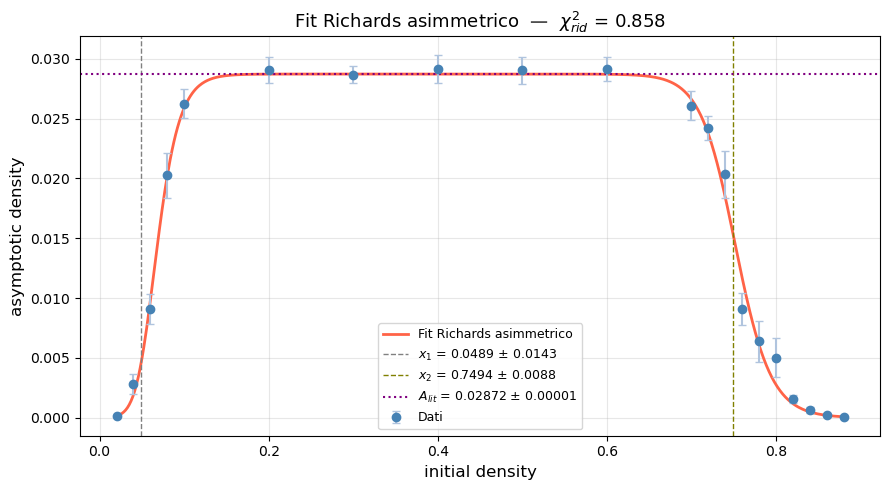

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, differential_evolution

#  Valore A dalla letteratura 
A_lit     = 0.02872
A_lit_err = 0.00001

#Modello Richards
def richards(x, k, x0, nu):
    arg     = np.clip(-k * (x - x0), -100, 100)  
    nu_safe = np.maximum(nu, 0.01)                 
    return 1 / (1 + np.exp(arg)) ** (1 / nu_safe)

'''Idea: stimo separateamente i due fronti con parametri diversi perchè 
assimetrici e poi li metto insieme'''
def model_trap(x, x1, x2, k1, k2, nu1, nu2):
    salita  = richards(x,  k1,  x1,  nu1)
    discesa = richards(-x, k2, -x2,  nu2)
    return A_lit * salita * discesa
'''
Per avere un'idea iniziale della stima dei fronti di salita e discesa 
calcoliamo dy. Usiamo convolve per avere ciascuna stima non troppo influenzata 
dal singolo punto ma analizziamo i dati a gruppi di 3 (ragionevole, 
fronti lunghi circa 6) centrandoci nel punto dove è calcolato il dy 
originario.
'''
#Stima automatica dei fronti
'''stimo i fronti come punti a massima (salita) e minima (discesa, 
massima in negativo), sono i punti di flesso
'''
threshold = y.max() * 0.05   # ignora punti sotto il 5% del massimo
mask_sig  = y > threshold

dy        = np.gradient(y[mask_sig], x[mask_sig])
dy_smooth = np.convolve(dy, np.ones(3) / 3, mode='same')

x1_guess  = x[mask_sig][np.argmax(dy_smooth)]
x2_guess  = x[mask_sig][np.argmin(dy_smooth)]
print(f"Fronti rilevati: x1 ≈ {x1_guess:.4f},  x2 ≈ {x2_guess:.4f}")

# Bounds per Differential Evolution 
'''usiamo la funzione di scipy differential evolution per avere usa 
stima dei parametri iniziali. Le diamo da minimizzare il chi quadro. Ragiona 
creando 5000 generazioni ciascuna da 15 individui per numero di par (90 
nel nostro caso). all'interno dei bound prende iniziaalmente in modo casuale
15 vettori nello spazio 6D, calcola il chi2 e sceglie il minimo,
va avanti così sostituendo nel confronto tra generazioni solo i casi se si ottiene
un chi2 minore. serve farlo prima del classico fit perchè
i parametri A, k₁, k₂, ν₁, ν₂ sono fortemente correlati, è possibile
aumentare A e diminuire k, oppure modificare ν, ottenendo curve quasi indistinguibili.
mentre curve fit fa una stima un parametero alla volta, il metodo de lavora su tutti
i parametri insieme, come serve nel nostro caso con parametri correlati'''

bounds_de = [
    ((x1_guess - 0.02), (x1_guess + 0.02)), # x1
    ((x2_guess - 0.02), (x2_guess + 0.02)),  # x2 dentro i dati
    (1.0, 1000.0),  # k1
    (1.0, 1000.0),  # k2
    (0.05, 3.0),  # nu1 — range ristretto per stabilità
    (0.05, 3.0),  # nu2
]

def chi2(params):
    try:
        return np.sum(((y - model_trap(x, *params)) / sigma_y) ** 2)
    except Exception:
        return 1e10


result_de = differential_evolution(
    chi2, bounds_de,
    seed=42, maxiter=5000, tol=1e-12, #mettiamo un limite di convergenza vicino alla precisione raggiungibile con i float
    polish=True, init='sobol' # 'sobol' sequenza quasi-casuale più uniforme di random
)

print(f"  converged: {result_de.success},  chi2 = {result_de.fun:.4f}")
print(f"  DE params: x1={result_de.x[0]:.4f}, x2={result_de.x[1]:.4f}, "
      f"k1={result_de.x[2]:.1f}, k2={result_de.x[3]:.1f}, "
      f"nu1={result_de.x[4]:.4f}, nu2={result_de.x[5]:.4f}")


'''ci serve comunque ancora il curve fit per avere parametri più precisi e matrice
di covarianza'''

# Bounds per curve_fit list comp. per rubarli da quelli del de
lower = [b[0] for b in bounds_de] 
upper = [b[1] for b in bounds_de]
bounds_cf = (lower, upper)

#Curve-fit
popt, pcov = curve_fit(
    model_trap, x, y,
    sigma = sigma_y, absolute_sigma = True,
    p0 = result_de.x,
    bounds = bounds_cf,    
    maxfev = 20000
)
errs = np.sqrt(np.diag(pcov))
x1_f, x2_f, k1_f, k2_f, nu1_f, nu2_f = popt

chi2_fit = np.sum(((y - model_trap(x, *popt)) / sigma_y) ** 2)
ndof     = len(x) - len(popt)


print(f"\n  A   = {A_lit:.5f}  ±  {A_lit_err:.5f}   (da letteratura)")
print(f"  x1  = {x1_f:.5f}  ±  {errs[0]:.5f}")
print(f"  x2  = {x2_f:.5f}  ±  {errs[1]:.5f}")
print(f"  k1  = {k1_f:.2f}   ±  {errs[2]:.2f}")
print(f"  k2  = {k2_f:.2f}   ±  {errs[3]:.2f}")
print(f"  nu1 = {nu1_f:.4f}  ±  {errs[4]:.4f}")
print(f"  nu2 = {nu2_f:.4f}  ±  {errs[5]:.4f}")

print(f"\n  chi2 ridotto = {chi2_fit/ndof:.3f}  (ndof = {ndof})")

'''per avere una stima di A facciamo semplicemente la media pesata dei dati del plateau '''
#Stima indipendente di A e compatibilità con letteratura
mask_plateau = (x > x1_f + (x2_f - x1_f) * 0.2) & \
               (x < x2_f - (x2_f - x1_f) * 0.2)

if mask_plateau.sum() > 0:
    pesi      = 1 / sigma_y[mask_plateau]**2
    A_mio     = np.sum(pesi * y[mask_plateau]) / np.sum(pesi)
    A_mio_err = 1 / np.sqrt(np.sum(pesi))
    z         = (A_mio - A_lit) / np.sqrt(A_mio_err**2 + A_lit_err**2)
    print(f"\n  A misurato    = {A_mio:.5f} ± {A_mio_err:.5f}")
    print(f"  A letteratura = {A_lit:.5f} ± {A_lit_err:.5f}")
    print(f"  Compatibilità: z = {z:.2f} sigma  "
          f"{'OK' if abs(z) < 2 else 'non compatibili'} al 95%\n")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(x, y, yerr=sigma_y, fmt='o', color='steelblue',
            ecolor='lightsteelblue', elinewidth=1.5, capsize=3,
            label='Dati', zorder=3)

_pts = np.linspace(x.min(), x.max(), 800)
ax.plot(_pts, model_trap(_pts, *popt), color='tomato', lw=2,
        label='Fit Richards asimmetrico')

ax.axvline(x1_f,  color='gray',   linestyle='--', lw=1,
           label=f'$x_1$ = {x1_f:.4f} ± {errs[0]:.4f}')
ax.axvline(x2_f,  color='olive',  linestyle='--', lw=1,
           label=f'$x_2$ = {x2_f:.4f} ± {errs[1]:.4f}')
ax.axhline(A_lit, color='purple', linestyle=':',  lw=1.5,
           label=f'$A_{{lit}}$ = {A_lit:.5f} ± {A_lit_err:.5f}')

ax.set_xlabel('initial density', fontsize=12)
ax.set_ylabel('asymptotic density', fontsize=12)
ax.set_title(f'Fit Richards asimmetrico  —  $\\chi^2_{{rid}}$ = {chi2_fit/ndof:.3f}',
             fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
from scipy.optimize import minimize_scalar

#Calcolo flessi come massimo/minimo della derivata numerica del modello

_pts = np.linspace(x.min(), x.max(), 10000)
_y   = model_trap(_pts, *popt)
_dy  = np.gradient(_y, _pts)

# flesso salita = massimo della derivata
idx_f1   = np.argmax(_dy)
x1_flesso = _pts[idx_f1]

# flesso discesa = minimo della derivata
idx_f2   = np.argmin(_dy)
x2_flesso = _pts[idx_f2]

print(f"Flesso salita:  x1_flesso = {x1_flesso:.4f}")
print(f"Flesso discesa: x2_flesso = {x2_flesso:.4f}")

Flesso salita:  x1_flesso = 0.0645
Flesso discesa: x2_flesso = 0.7513


C:\Users\mazzi\AppData\Local\Temp\ipykernel_18776\3743032608.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


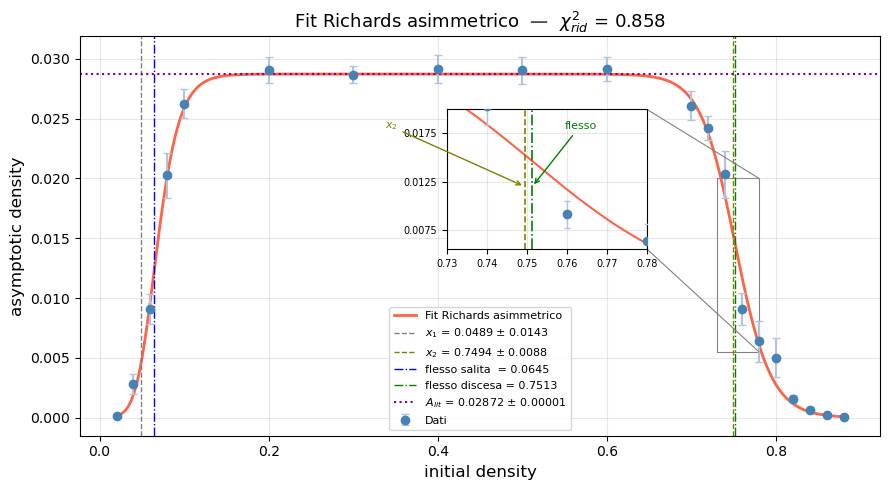

In [40]:
#plot con anche il flesso
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(x, y, yerr=sigma_y, fmt='o', color='steelblue',
            ecolor='lightsteelblue', elinewidth=1.5, capsize=3,
            label='Dati', zorder=3)
ax.plot(_pts, _y, color='tomato', lw=2, label='Fit Richards asimmetrico')
ax.axvline(x1_f,      color='gray',   linestyle='--', lw=1,
           label=f'$x_1$ = {x1_f:.4f} ± {errs[0]:.4f}')
ax.axvline(x2_f,      color='olive',  linestyle='--', lw=1,
           label=f'$x_2$ = {x2_f:.4f} ± {errs[1]:.4f}')
ax.axvline(x1_flesso, color='blue',   linestyle='-.', lw=1,
           label=f'flesso salita  = {x1_flesso:.4f}')
ax.axvline(x2_flesso, color='green',  linestyle='-.', lw=1,
           label=f'flesso discesa = {x2_flesso:.4f}')
ax.axhline(A_lit, color='purple', linestyle=':', lw=1.5,
           label=f'$A_{{lit}}$ = {A_lit:.5f} ± {A_lit_err:.5f}')
ax.set_xlabel('initial density', fontsize=12)
ax.set_ylabel('asymptotic density', fontsize=12)
ax.set_title(f'Fit Richards asimmetrico  —  $\\chi^2_{{rid}}$ = {chi2_fit/ndof:.3f}', fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Inset zoom fronte di discesa ──────────────────────────────────────────────
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# posizione e dimensione dell'inset: modifica bbox_to_anchor per spostarlo
ax_inset = inset_axes(ax, width="25%", height="35%",
                      bbox_to_anchor=(0.45, 0.45, 1, 1),
                      bbox_transform=ax.transAxes,
                      loc='lower left')

ax_inset.errorbar(x, y, yerr=sigma_y, fmt='o', color='steelblue',
                  ecolor='lightsteelblue', elinewidth=1.0, capsize=2, zorder=3)
ax_inset.plot(_pts, _y, color='tomato', lw=1.5)
ax_inset.axvline(x2_f,      color='olive', linestyle='--', lw=1.2)
ax_inset.axvline(x2_flesso, color='green', linestyle='-.', lw=1.2)

ax_inset.annotate('$x_2$', xy=(x2_f, 0.012),
                  xytext=(x2_f - 0.035, 0.018),
                  arrowprops=dict(arrowstyle='->', color='olive'),
                  color='olive', fontsize=8)
ax_inset.annotate('flesso', xy=(x2_flesso, 0.012),
                  xytext=(x2_flesso + 0.008, 0.018),
                  arrowprops=dict(arrowstyle='->', color='green'),
                  color='green', fontsize=8)

ax_inset.set_xlim(0.73, 0.78)
ax_inset.set_ylim(0.0055, 0.02)
ax_inset.set_yticks([0.0075, 0.0125, 0.0175])
ax_inset.tick_params(labelsize=7)
ax_inset.grid(True, alpha=0.3)

mark_inset(ax, ax_inset, loc1=1, loc2=4, fc="none", ec="0.5", lw=0.8)

plt.tight_layout()
plt.show()

A = 0.02893 ± 0.00043


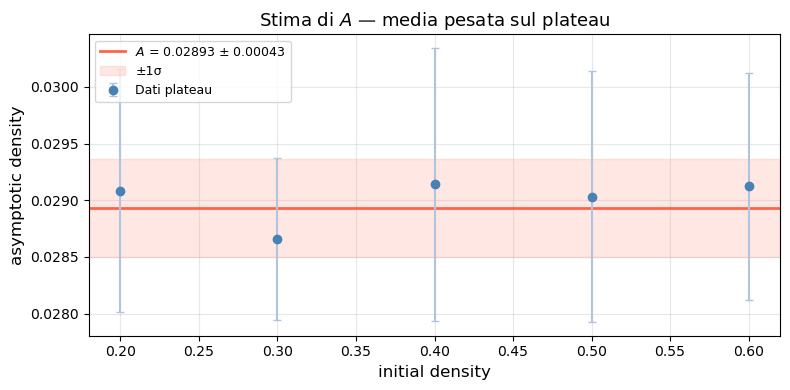

In [42]:
#Stima A con media pesata sul plateau
x_plat = x[mask_plateau]
y_plat = y[mask_plateau]
s_plat = sigma_y[mask_plateau]

pesi    = 1 / s_plat**2
A_fixed = np.sum(pesi * y_plat) / np.sum(pesi)
A_fixed_err = 1 / np.sqrt(np.sum(pesi))

print(f"A = {A_fixed:.5f} ± {A_fixed_err:.5f}")

#Plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.errorbar(x_plat, y_plat, yerr=s_plat, fmt='o', color='steelblue',
            ecolor='lightsteelblue', elinewidth=1.5, capsize=3,
            label='Dati plateau', zorder=3)

ax.axhline(A_fixed, color='tomato', lw=2,
           label=f'$A$ = {A_fixed:.5f} ± {A_fixed_err:.5f}')
ax.axhspan(A_fixed - A_fixed_err, A_fixed + A_fixed_err,
           alpha=0.15, color='tomato', label='±1σ')

ax.set_xlabel('initial density', fontsize=12)
ax.set_ylabel('asymptotic density', fontsize=12)
ax.set_title('Stima di $A$ — media pesata sul plateau', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

x1_guess_rough = 0.0800
x2_guess_rough = 0.7600
Fit lineare plateau: q = 0.02865 ± 0.00128, m = 0.00074 ± 0.00315
A stimato al centro plateau: 0.02895 ± 0.00044
comp di m con 0: 0.2339377653057339


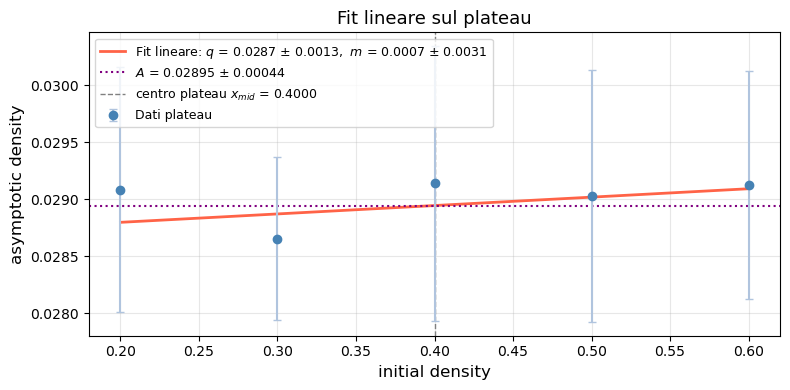

In [41]:
# Calcola x1 e x2 guess automaticamente dai dati
x1_guess_rough = x[np.argmax(np.convolve(np.gradient(y, x), np.ones(7)/7, mode='same'))]
x2_guess_rough = x[np.argmin(np.convolve(np.gradient(y, x), np.ones(7)/7, mode='same'))]

print(f"x1_guess_rough = {x1_guess_rough:.4f}")
print(f"x2_guess_rough = {x2_guess_rough:.4f}")

from scipy.stats import linregress

# ── Stima A con fit lineare sul plateau ───────────────────────────────────────
mask_plateau = (x > x1_guess_rough + (x2_guess_rough - x1_guess_rough) * 0.15) & \
               (x < x2_guess_rough - (x2_guess_rough - x1_guess_rough) * 0.15)

x_plat = x[mask_plateau]
y_plat = y[mask_plateau]
s_plat = sigma_y[mask_plateau]

# fit lineare pesato con curve_fit (linregress non gestisce sigma)
def lineare(x, q, m):
    return q + m * x

popt_lin, pcov_lin = curve_fit(lineare, x_plat, y_plat,
                                sigma=s_plat, absolute_sigma=True)
q_fit, m_fit = popt_lin
q_err, m_err = np.sqrt(np.diag(pcov_lin))

# A è il valore medio della retta sul plateau (valutata al centro)
x_mid   = (x_plat.min() + x_plat.max()) / 2
A_fixed = lineare(x_mid, q_fit, m_fit)

# propagazione dell'errore su A = q + m*x_mid
A_fixed_err = np.sqrt(q_err**2 + (x_mid * m_err)**2 + 
                       2 * x_mid * pcov_lin[0,1])  # include covarianza q,m

print(f"Fit lineare plateau: q = {q_fit:.5f} ± {q_err:.5f}, "
      f"m = {m_fit:.5f} ± {m_err:.5f}")
print(f"A stimato al centro plateau: {A_fixed:.5f} ± {A_fixed_err:.5f}")
print(f'comp di m con 0: {m_fit/m_err}')

fig, ax = plt.subplots(figsize=(8, 4))

ax.errorbar(x_plat, y_plat, yerr=s_plat, fmt='o', color='steelblue',
            ecolor='lightsteelblue', elinewidth=1.5, capsize=3,
            label='Dati plateau', zorder=3)

_pts = np.linspace(x_plat.min(), x_plat.max(), 300)
ax.plot(_pts, lineare(_pts, q_fit, m_fit), color='tomato', lw=2,
        label=f'Fit lineare: $q$ = {q_fit:.4f} ± {q_err:.4f},  $m$ = {m_fit:.4f} ± {m_err:.4f}')

ax.axhline(A_fixed, color='purple', linestyle=':', lw=1.5,
           label=f'$A$ = {A_fixed:.5f} ± {A_fixed_err:.5f}')
ax.axvline(x_mid, color='gray', linestyle='--', lw=1,
           label=f'centro plateau $x_{{mid}}$ = {x_mid:.4f}')

ax.set_xlabel('initial density', fontsize=12)
ax.set_ylabel('asymptotic density', fontsize=12)
ax.set_title('Fit lineare sul plateau', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()